## Fallbeispiele für Unsupervised Learning & Dimensionsreduktion
## 1. Grundlagen und Motivation

Beispiel: Exploration eines E-Commerce-Datensatzes
Für dieses Beispiel nutzen wir den öffentlichen "Online Retail" Datensatz, der Transaktionsdaten eines britischen Online-Händlers enthält. Wir werden zeigen, wie unüberwachtes Lernen hilft, verborgene Strukturen in den Daten zu finden, ohne vorher definierte Labels zu benötigen.


In [ ]:
import sys; sys.path.insert(0, '..')
import yaml
from pathlib import Path
from src.data_loading import set_seeds
from src.plotting import setup_plot_style
from src.evaluation import evaluate_clustering

cfg = yaml.safe_load(open(Path('../configs/default.yaml')))
set_seeds(cfg['random_seed'])
setup_plot_style(cfg)

# --- Beispiel 1: Online Retail ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

retail_data = pd.read_excel('https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx')
retail_data = retail_data.dropna()
retail_data = retail_data[retail_data['Quantity'] > 0]

customer_product = retail_data.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().unstack().fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(customer_product.iloc[:20, :20], cmap='YlGnBu', annot=False)
plt.title('Kunden-Produkt-Matrix (Ausschnitt)')
plt.xlabel('Produkte (StockCode)')
plt.ylabel('Kunden (CustomerID)')
plt.show()

print(f'Anzahl verschiedener Kunden: {customer_product.shape[0]}')
print(f'Anzahl verschiedener Produkte: {customer_product.shape[1]}')
print(f'Spaerlichkeit der Matrix: {(customer_product == 0).sum().sum() / (customer_product.shape[0] * customer_product.shape[1]):.2%}')

In diesem Beispiel sehen wir, dass der Datensatz hochdimensional ist (viele Produkte) und sehr spärlich (die meisten Kunden kaufen nur wenige der verfügbaren Produkte). Diese Eigenschaften machen unüberwachtes Lernen besonders wertvoll, um Muster zu erkennen, die für das menschliche Auge nicht offensichtlich sind.

## 2. Clustering

Beispiel: Kundensegmentierung mit K-Means
Für dieses Beispiel verwenden wir den UCI "Mall Customer Segmentation" Datensatz, um Kundengruppen basierend auf deren Einkaufsverhalten zu identifizieren.

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


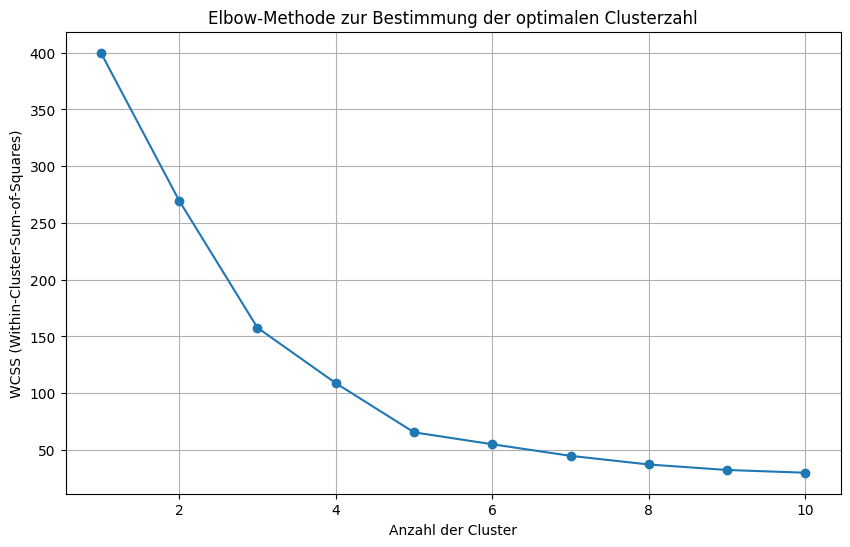

Silhouette Score: 0.555


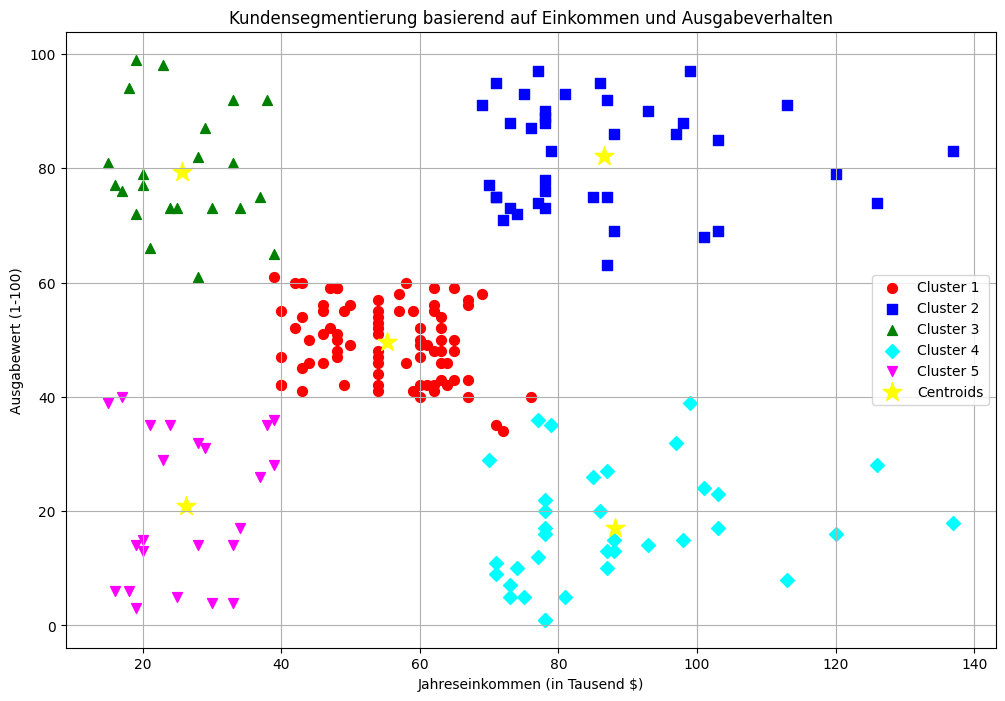


Durchschnittliche Werte pro Kundencluster:
         CustomerID    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                               
1             86.32  42.72               55.30                   49.52
2            162.00  32.69               86.54                   82.13
3             23.09  25.27               25.73                   79.36
4            164.37  41.11               88.20                   17.11
5             23.00  45.22               26.30                   20.91


In [3]:
# Importieren der notwendigen Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns

# Daten laden
customers = pd.read_csv("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv")

# Daten anzeigen
print(customers.head())

# Für unser Clustering verwenden wir nur numerische Features
X = customers.iloc[:, 3:5].values  # Annual Income und Spending Score

# Daten skalieren (wichtig für Clustering-Algorithmen)
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# Optimale Anzahl an Clustern mit Elbow-Methode finden
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualisierung der Elbow-Methode
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow-Methode zur Bestimmung der optimalen Clusterzahl')
plt.xlabel('Anzahl der Cluster')
plt.ylabel('WCSS (Within-Cluster-Sum-of-Squares)')
plt.grid(True)
plt.show()

# K-Means mit optimaler Clusterzahl (5) anwenden
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Silhouette-Score berechnen (Qualitätsmetrik für Clustering)
silhouette_avg = silhouette_score(X_scaled, y_kmeans)
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Visualisierung der Cluster
plt.figure(figsize=(12, 8))

# Originaldaten für Visualisierung zurücktransformieren
X_original = sc.inverse_transform(X_scaled)

# Farben und Marker für die Cluster
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
markers = ['o', 's', '^', 'D', 'v']

# Plotten der Datenpunkte mit Cluster-Farben
for i in range(5):
    plt.scatter(X_original[y_kmeans == i, 0], X_original[y_kmeans == i, 1], 
                s=50, c=colors[i], marker=markers[i], label=f'Cluster {i+1}')

# Plotten der Cluster-Zentren
centers = sc.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='yellow', marker='*', label='Centroids')

plt.title('Kundensegmentierung basierend auf Einkommen und Ausgabeverhalten')
plt.xlabel('Jahreseinkommen (in Tausend $)')
plt.ylabel('Ausgabewert (1-100)')
plt.legend()
plt.grid(True)
plt.show()

# Charakterisierung der Cluster
cluster_df = customers.copy()
cluster_df['Cluster'] = y_kmeans + 1  # Cluster von 1-5 nummerieren

# Durchschnittswerte pro Cluster berechnen
cluster_means = cluster_df.groupby('Cluster').mean(numeric_only=True).round(2)
print("\nDurchschnittliche Werte pro Kundencluster:")
print(cluster_means)


Dieses Beispiel zeigt, wie wir mit K-Means Clustering verschiedene Kundensegmente identifizieren können, basierend auf deren Einkommen und Ausgabeverhalten. Die visuelle Darstellung macht die natürlichen Gruppierungen in den Daten deutlich sichtbar. Die Identifikation dieser Segmente ermöglicht zielgerichtete Marketingaktionen und personalisierte Kundenansprache.

## 3. Evaluierung

### Beispiel: Evaluierung verschiedener Clustering-Algorithmen

Hier vergleichen wir verschiedene Clustering-Algorithmen auf dem Iris-Datensatz, der sich gut für die Visualisierung eignet.

In [4]:
# Importieren der notwendigen Bibliotheken
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Iris-Datensatz laden
iris = load_iris()
X = iris.data
y_true = iris.target  # Wir nutzen die wahren Labels nur für den Vergleich

# Daten skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verschiedene Clustering-Algorithmen anwenden
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Hierarchisches Clustering
agglom = AgglomerativeClustering(n_clusters=3)
y_agglom = agglom.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Dictionary mit den Clustering-Ergebnissen
clustering_results = {
    "K-Means": y_kmeans,
    "Agglomeratives Clustering": y_agglom,
    "DBSCAN": y_dbscan
}

# evaluate_clustering importiert aus src.evaluation

# Evaluierungen durchführen
evaluation_results = {}
for name, labels in clustering_results.items():
    evaluation_results[name] = evaluate_clustering(X_scaled, labels)

# Ergebnisse in DataFrame umwandeln für einfache Darstellung
eval_df = pd.DataFrame(evaluation_results).round(3)
print("Clustering-Evaluierung:")
print(eval_df)

# PCA für Visualisierung
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisierung der Clustering-Ergebnisse
plt.figure(figsize=(15, 10))
algorithms = list(clustering_results.keys())

for i, (name, labels) in enumerate(clustering_results.items()):
    plt.subplot(2, 2, i+1)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.8)
    
    # Hinzufügen von Clusterzentren für K-Means
    if name == "K-Means":
        centers_pca = pca.transform(kmeans.cluster_centers_)
        plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=100)
    
    plt.title(f"{name} Clustering")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    
    # Legende hinzufügen
    unique_labels = np.unique(labels)
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.viridis(i / max(1, len(unique_labels) - 1)), 
                          markersize=10) for i in range(len(unique_labels))]
    label_names = [f'Cluster {label}' if label != -1 else 'Noise' for label in unique_labels]
    plt.legend(handles, label_names)

# Letzte Subplot: Visualisierung der tatsächlichen Klassen
plt.subplot(2, 2, 4)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', alpha=0.8)
plt.title("Tatsächliche Klassen")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Legende für tatsächliche Klassen
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.viridis(i/2), markersize=10) for i in range(3)]
plt.legend(handles, iris.target_names)

plt.tight_layout()
plt.show()

# Barplot der Evaluierungsmetriken
plt.figure(figsize=(12, 6))

# Die Metriken in separaten Plots darstellen
metrics = ["Silhouette Score", "Calinski-Harabasz Score", "Davies-Bouldin Score"]

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    
    # Für Davies-Bouldin gilt: je niedriger, desto besser
    if metric == "Davies-Bouldin Score":
        bars = plt.bar(eval_df.columns, eval_df.loc[metric], color=['#ff9999', '#66b3ff', '#99ff99'])
        plt.title(f"{metric}\n(niedriger ist besser)")
    else:
        bars = plt.bar(eval_df.columns, eval_df.loc[metric], color=['#ff9999', '#66b3ff', '#99ff99'])
        plt.title(f"{metric}\n(höher ist besser)")
    
    plt.xticks(rotation=45)
    plt.ylabel("Score")
    
    # Werte über den Balken anzeigen
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



In diesem Beispiel evaluieren wir verschiedene Clustering-Algorithmen mit internen Metriken wie dem Silhouette-Koeffizienten, dem Calinski-Harabasz-Index und dem Davies-Bouldin-Index. Diese Metriken helfen uns, die Qualität des Clusterings zu bewerten, ohne auf externe Labels angewiesen zu sein. Der Vergleich der Algorithmen zeigt, dass verschiedene Methoden unterschiedliche Ergebnisse liefern können und die Wahl des richtigen Algorithmus vom Anwendungsfall abhängt.

## 4. Dimensionsreduktion

### Beispiel: Gesichtserkennung mit PCA und t-SNE

Hier nutzen wir den bekannten Olivetti Faces-Datensatz, um zu zeigen, wie Dimensionsreduktion hilft, hochdimensionale Daten zu visualisieren und wichtige Merkmale zu extrahieren.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/danielambach/scikit_learn_data
Datensatzgröße: (400, 4096)
Anzahl der Personen: 40


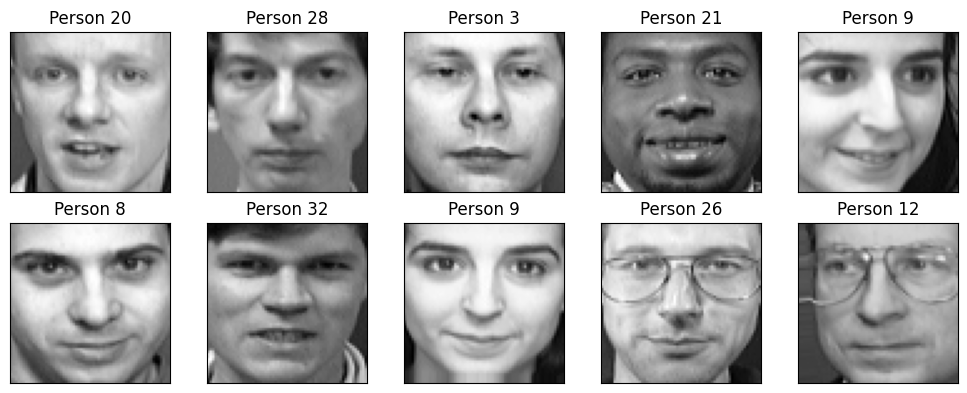

PCA durchgeführt in 0.06 Sekunden
Reduzierte Dimensionen: (400, 50)


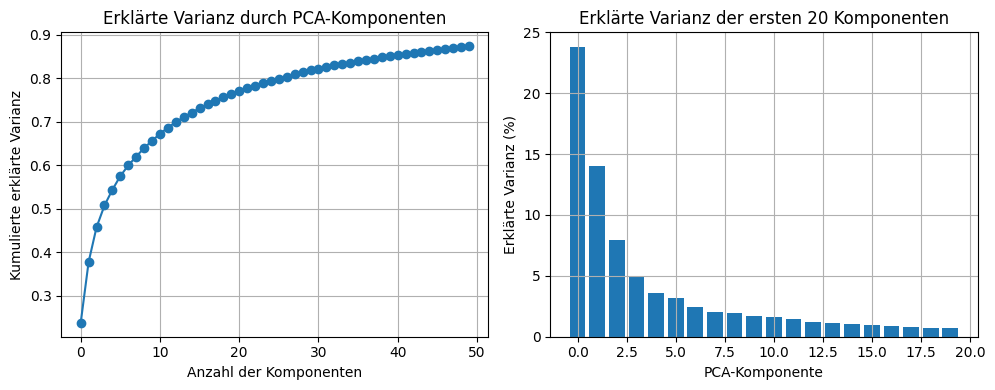

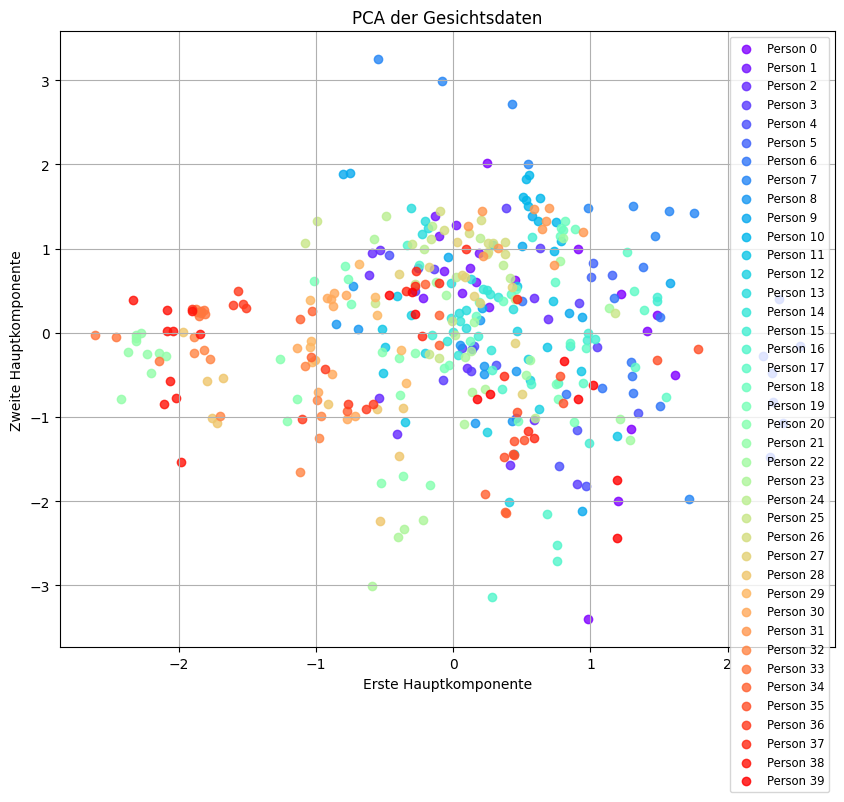

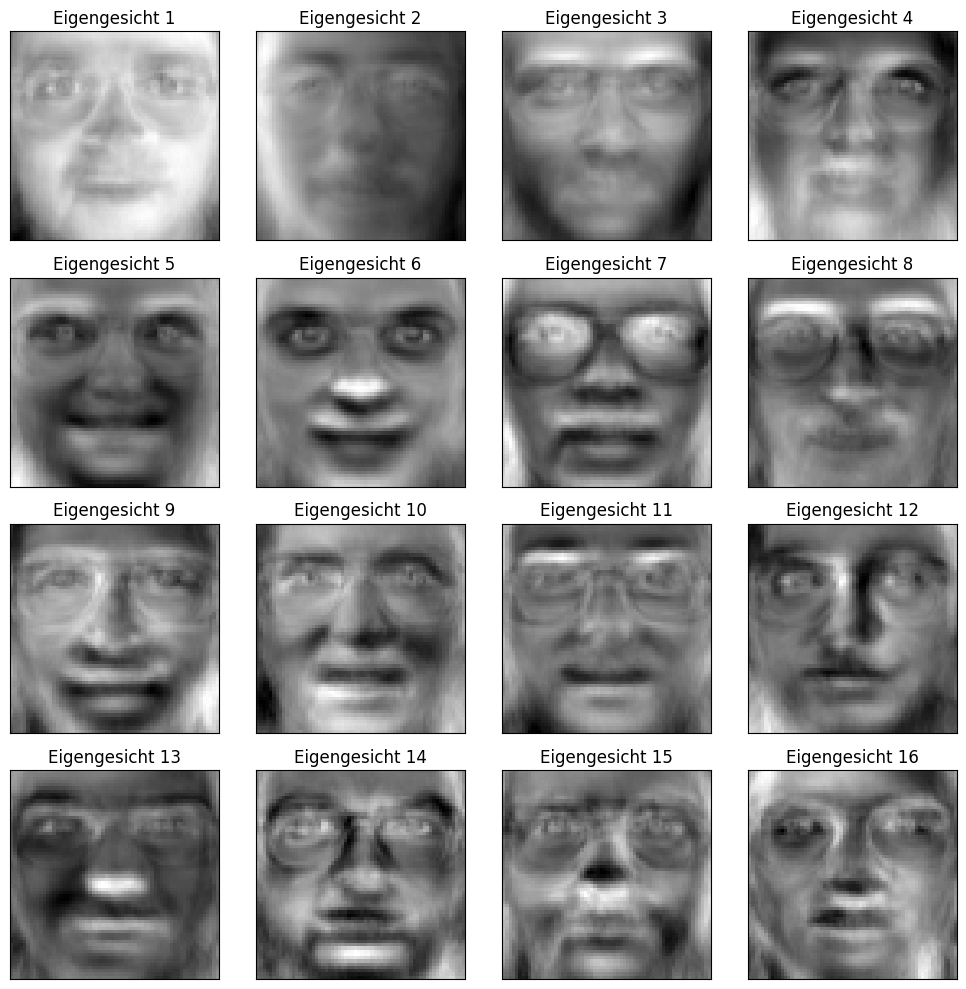

/opt/homebrew/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE durchgeführt in 0.71 Sekunden


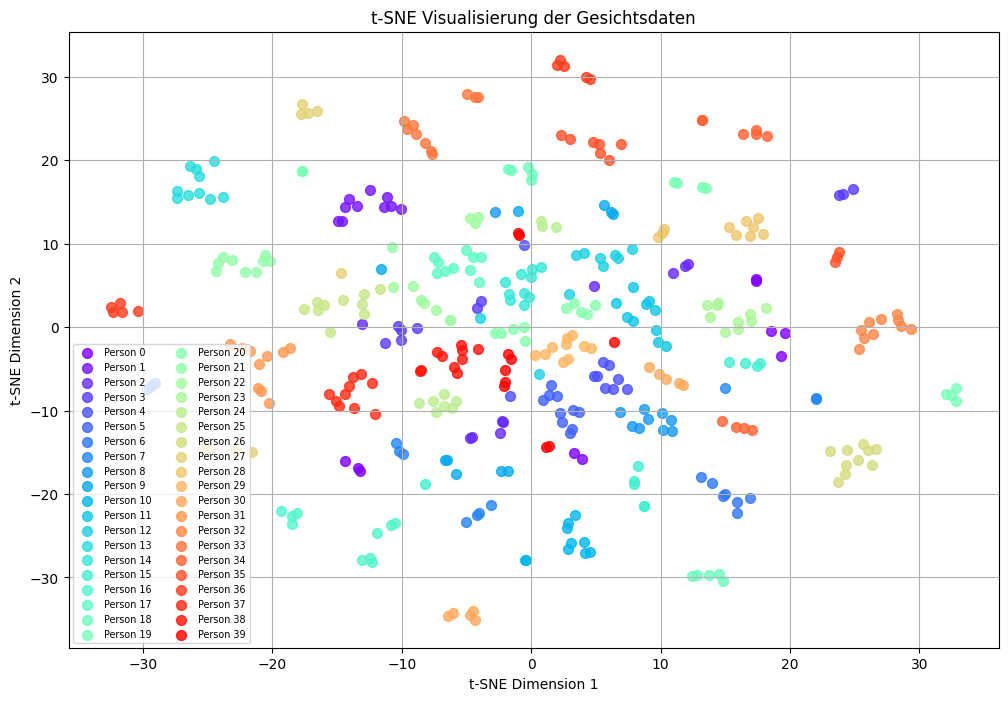

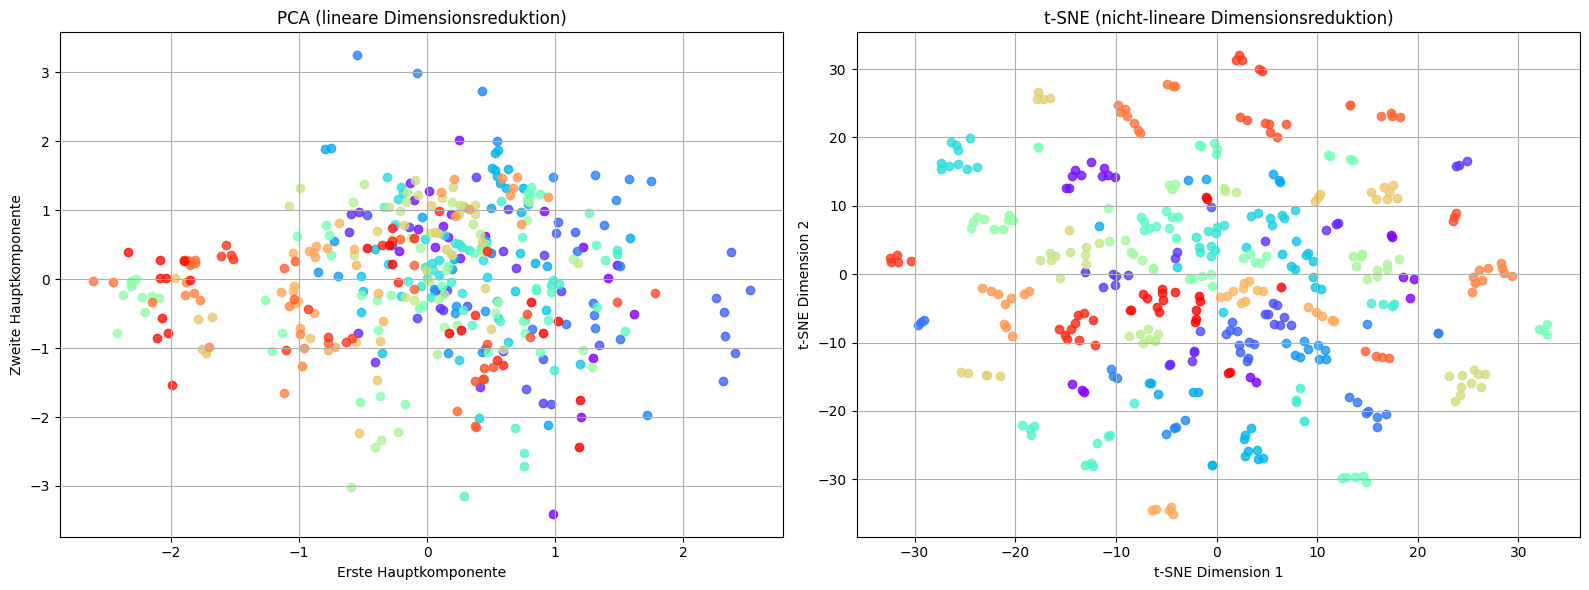

In [5]:
# Importieren der notwendigen Bibliotheken
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time

# Olivetti Faces Datensatz laden
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data
y = faces.target

print(f"Datensatzgröße: {X.shape}")
print(f"Anzahl der Personen: {len(np.unique(y))}")

# Einige Beispielbilder anzeigen
fig, axes = plt.subplots(2, 5, figsize=(10, 4), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    ax.imshow(faces.images[i], cmap='gray')
    ax.set_title(f'Person {y[i]}')
plt.tight_layout()
plt.show()

# PCA für Dimensionsreduktion
n_components = 50  # Reduzieren auf 50 Komponenten
start_time = time.time()
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True)
X_pca = pca.fit_transform(X)
print(f"PCA durchgeführt in {time.time() - start_time:.2f} Sekunden")
print(f"Reduzierte Dimensionen: {X_pca.shape}")

# Erklärte Varianz visualisieren
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-')
plt.xlabel('Anzahl der Komponenten')
plt.ylabel('Kumulierte erklärte Varianz')
plt.title('Erklärte Varianz durch PCA-Komponenten')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(20), pca.explained_variance_ratio_[:20] * 100)
plt.xlabel('PCA-Komponente')
plt.ylabel('Erklärte Varianz (%)')
plt.title('Erklärte Varianz der ersten 20 Komponenten')
plt.grid(True)
plt.tight_layout()
plt.show()

# Erste zwei PCA-Komponenten visualisieren
plt.figure(figsize=(10, 8))
unique_targets = len(np.unique(y))
colors = plt.cm.rainbow(np.linspace(0, 1, unique_targets))

for i, c in zip(range(unique_targets), colors):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
               c=c.reshape(1, -1), label=f'Person {i}', alpha=0.8)

plt.xlabel('Erste Hauptkomponente')
plt.ylabel('Zweite Hauptkomponente')
plt.title('PCA der Gesichtsdaten')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.show()

# Eigengesichter visualisieren (die ersten 16)
fig, axes = plt.subplots(4, 4, figsize=(10, 10), subplot_kw={'xticks': [], 'yticks': []})
for i, (ax, comp) in enumerate(zip(axes.ravel(), pca.components_[:16])):
    ax.imshow(comp.reshape(faces.images[0].shape), cmap='gray')
    ax.set_title(f'Eigengesicht {i+1}')
plt.tight_layout()
plt.show()

# t-SNE für nicht-lineare Dimensionsreduktion
start_time = time.time()
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
# t-SNE auf die PCA-reduzierten Daten anwenden (schneller und stabiler)
X_tsne = tsne.fit_transform(X_pca)
print(f"t-SNE durchgeführt in {time.time() - start_time:.2f} Sekunden")

# t-SNE Ergebnisse visualisieren
plt.figure(figsize=(12, 8))
for i, c in zip(range(unique_targets), colors):
    plt.scatter(X_tsne[y == i, 0], X_tsne[y == i, 1], 
               c=c.reshape(1, -1), label=f'Person {i}', alpha=0.8, s=50)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualisierung der Gesichtsdaten')
plt.legend(loc='best', fontsize='x-small', ncol=2)
plt.grid(True)
plt.show()

# Vergleich zwischen PCA und t-SNE
plt.figure(figsize=(16, 6))

# PCA Visualisierung
plt.subplot(1, 2, 1)
for i, c in zip(range(unique_targets), colors):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
               c=c.reshape(1, -1), label=f'Person {i}', alpha=0.8)
plt.xlabel('Erste Hauptkomponente')
plt.ylabel('Zweite Hauptkomponente')
plt.title('PCA (lineare Dimensionsreduktion)')
plt.grid(True)

# t-SNE Visualisierung
plt.subplot(1, 2, 2)
for i, c in zip(range(unique_targets), colors):
    plt.scatter(X_tsne[y == i, 0], X_tsne[y == i, 1], 
               c=c.reshape(1, -1), label=f'Person {i}', alpha=0.8)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE (nicht-lineare Dimensionsreduktion)')
plt.grid(True)

plt.tight_layout()
plt.show()


Dieses Beispiel demonstriert, wie mit PCA und t-SNE hochdimensionale Gesichtsdaten auf wenige Dimensionen reduziert werden können, um die wichtigsten Merkmale zu extrahieren und die Daten zu visualisieren. Die PCA identifiziert die Hauptachsen der Varianz in den Daten (Eigengesichter), während t-SNE lokale Nachbarschaftsbeziehungen bewahrt und somit komplexere Strukturen in den Daten sichtbar macht.

## 5. Autoencoder

### Beispiel: Autoencoder für Bilddatenkompression mit MNIST
Hier implementieren wir einen Autoencoder für den MNIST-Datensatz, um zu zeigen, wie neuronale Netze für nicht-lineare Dimensionsreduktion eingesetzt werden können.


> **Hinweis:** TensorFlow muss installiert sein (`pip install -r requirements.txt`)

In [3]:
# Importieren der notwendigen Bibliotheken
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.utils import plot_model
import tensorflow as tf
from sklearn.manifold import TSNE

# Seeds bereits global gesetzt via set_seeds()

# MNIST-Datensatz laden
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Daten normalisieren
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Autoencoder-Architektur definieren
input_img = Input(shape=(28, 28))
flat = Flatten()(input_img)

# Encoder
encoded = Dense(128, activation='relu')(flat)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(10, activation='relu', name='latent_space')(encoded)  # Latenter Raum mit 10 Dimensionen

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(28*28, activation='sigmoid')(decoded)
output = Reshape((28, 28))(decoded)

# Modell zusammensetzen
autoencoder = Model(input_img, output)
encoder = Model(input_img, latent)

# Modell kompilieren
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Modellzusammenfassung anzeigen
autoencoder.summary()

# Modell trainieren
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Verlauf des Trainings visualisieren
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Verlust während des Trainings')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid(True)

# Rekonstruierte Bilder erzeugen
decoded_imgs = autoencoder.predict(x_test)

# Originale und rekonstruierte Bilder visualisieren
n = 10  # Anzahl der anzuzeigenden Bilder
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Original: {y_test[i]}")
    plt.axis('off')
    
    # Rekonstruktion
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.title("Rekonstruiert")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Latenten Raum visualisieren
# Kodieren der Testdaten in den latenten Raum
latent_vectors = encoder.predict(x_test)

# t-SNE auf den latenten Vektoren anwenden für Visualisierung
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
latent_tsne = tsne.fit_transform(latent_vectors)

# t-SNE-Visualisierung des latenten Raums mit Klassenfarben
plt.figure(figsize=(12, 10))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=y_test, cmap='tab10', alpha=0.8, s=5)
plt.colorbar(scatter, ticks=range(10), label='Ziffer')
plt.title('t-SNE Visualisierung des latenten Raums')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

# Interpolation im latenten Raum
# Zwei Ziffern auswählen
digit1_idx = np.where(y_test == 3)[0][0]  # Eine 3
digit2_idx = np.where(y_test == 8)[0][0]  # Eine 8

# Latente Vektoren für diese Ziffern extrahieren
latent_digit1 = encoder.predict(x_test[digit1_idx:digit1_idx+1])
latent_digit2 = encoder.predict(x_test[digit2_idx:digit2_idx+1])

# Interpolieren zwischen den beiden latenten Vektoren
n_steps = 10
latent_interp = np.zeros((n_steps, latent_vectors.shape[1]))

for i in range(n_steps):
    alpha = i / (n_steps - 1)
    latent_interp[i] = (1 - alpha) * latent_digit1 + alpha * latent_digit2

# Decodieren der interpolierten Vektoren
decoded_interp = autoencoder.decoder.predict(latent_interp)

# Visualisieren der Interpolation
plt.figure(figsize=(15, 3))
for i in range(n_steps):
    ax = plt.subplot(1, n_steps, i + 1)
    plt.imshow(decoded_interp[i].reshape(28, 28), cmap='gray')
    plt.title(f"α={i/(n_steps-1):.1f}")
    plt.axis('off')
plt.suptitle(f"Interpolation zwischen Ziffer {y_test[digit1_idx]} und {y_test[digit2_idx]}")
plt.tight_layout()
plt.show()

# Anomalieerkennung mit Rekonstruktionsfehler
mse = np.mean(np.square(x_test - decoded_imgs), axis=(1, 2))

# Visualisieren der Verteilung des Rekonstruktionsfehlers nach Klassen
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.hist(mse[y_test == i], alpha=0.7, bins=30, label=f'Ziffer {i}')
plt.xlabel('Rekonstruktionsfehler (MSE)')
plt.ylabel('Anzahl')
plt.title('Verteilung des Rekonstruktionsfehlers nach Ziffern')
plt.legend()
plt.grid(True)
plt.show()

# Bilder mit hohem und niedrigem Rekonstruktionsfehler anzeigen
sorted_idx = np.argsort(mse)
best_idx = sorted_idx[:5]  # Niedrigster Fehler
worst_idx = sorted_idx[-5:]  # Höchster Fehler

plt.figure(figsize=(20, 8))
for i, idx in enumerate(best_idx):
    # Original mit niedrigem Fehler
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Original {y_test[idx]}\nMSE: {mse[idx]:.4f}")
    plt.axis('off')
    
    # Rekonstruktion mit niedrigem Fehler
    plt.subplot(4, 5, i + 6)
    plt.imshow(decoded_imgs[idx], cmap='gray')
    plt.title("Rekonstruiert")
    plt.axis('off')

for i, idx in enumerate(worst_idx):
    # Original mit hohem Fehler
    plt.subplot(4, 5, i + 11)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Original {y_test[idx]}\nMSE: {mse[idx]:.4f}")
    plt.axis('off')
    
    # Rekonstruktion mit hohem Fehler
    plt.subplot(4, 5, i + 16)
    plt.imshow(decoded_imgs[idx], cmap='gray')
    plt.title("Rekonstruiert")
    plt.axis('off')

plt.tight_layout()
plt.show()


In diesem Beispiel haben wir einen Autoencoder implementiert, der Bilder in einen niedrigdimensionalen latenten Raum komprimiert und dann rekonstruiert. Diese Technik kann für Dimensionsreduktion, Datenkompression und Anomalieerkennung verwendet werden. Die Visualisierung des latenten Raums zeigt, wie der Autoencoder die Ziffern automatisch in sinnvolle Gruppen organisiert hat, obwohl er während des Trainings keine Klasseninformationen erhalten hat